In [4]:
import geopandas as gpd
import os

In [5]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std', 'eccentricity', 'solidity',
       'mean_intensity', 'perimeter', 'compactness', 'shape_index', 'area']

target = 'OBSERV_GROUP'

label_map = {
    '0' : 'Building',
    '11' : 'Urban',
    '12' : 'Highway',
    '21' : 'Seasonal crops',
    '22' : 'Permanent crops',
    '23' : 'Pasture',
    '31' : 'Forest',
    '32' : 'Grassland',
    '33' : 'Bare areas',
    '51' : 'Water'
}

In [6]:
train_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))

test_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))

print(train_gdf.columns)


Index(['CODIGO', 'OBSERV', 'INSUMO', 'APOYO', 'ASIGNACION', 'Asignado', 'OAM',
       'area', 'url_type', 'download_url', 'poly_id', 'image_uid', 'r_mean',
       'r_median', 'r_std', 'r_var', 'g_mean', 'g_median', 'g_std', 'g_var',
       'b_mean', 'b_median', 'b_std', 'b_var', 'eccentricity', 'solidity',
       'mean_intensity', 'perimeter', 'compactness', 'shape_index',
       'CODIGO_GROUP', 'geometry'],
      dtype='object')


In [7]:

train_gdf['OBSERV_GROUP'] = train_gdf['CODIGO_GROUP'].replace(label_map)

test_gdf['OBSERV_GROUP'] = test_gdf['CODIGO_GROUP'].replace(label_map)

X_train = train_gdf[features]
y_train = train_gdf[target]
X_test = test_gdf[features]
y_test = test_gdf[target]

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def compute_accuracy(classifier, X, y, train_gdf):
    """Computes the overall accuracy and classification report of the classifier on the given data.

    Args:
        classifier (_classifier_): Trained classifier.
        X (_type_): Features.
        y (_type_): True labels.
        train_gdf (_type_): Training GeoDataFrame for label extraction.
        
    Returns:
        overall_accuracy (float): Overall accuracy of the classifier.
        classification_accuracy (str): Classification report as a string.
    """
    y_pred = classifier.predict(X)
    overall_accuracy = accuracy_score(y, y_pred)
    classification_accuracy= classification_report(y, y_pred,zero_division=1)
    
    labels = list(train_gdf['OBSERV_GROUP'].unique())

    cm = confusion_matrix(y, y_pred, labels=labels)

    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels, )
    
    cm_norm = confusion_matrix(y, y_pred, labels=labels, normalize='true')
    
    cmd_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)

    # Add gaps between the two plots
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
    cmd.plot(ax=ax[0], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    cmd_norm.plot(ax=ax[1], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    ax[0].set_title('Confusion Matrix')
    ax[1].set_title('Normalized Confusion Matrix')
    plt.show()
    return overall_accuracy, classification_accuracy 


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [20, 30, 40],
    'min_samples_split': [2, 4, 6],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    scoring='f1_macro'
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=20, min_samples_split=2, n_estimators=200; total time=   0.9s
[CV] END max_depth=20, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END max_depth=20, min_samples_split=2, n_estimators=200; total time=   0.9s
[CV] END max_depth=20, min_samples_split=2, n_estimators=200; total time=   1.0s
[CV] END max_depth=20, min_samples_split=2, n_estimators=200; total time=   1.1s
[CV] END max_depth=20, min_samples_split=4, n_estimators=100; total time=   0.7s
[CV] END max_depth=20, min_samples_split=4, n_e

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [20, 30, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


Best Hyperparameters: {'max_depth': 30, 'min_samples_split': 4, 'n_estimators': 100}
0.43 f1_macro with a standard deviation of 0.04


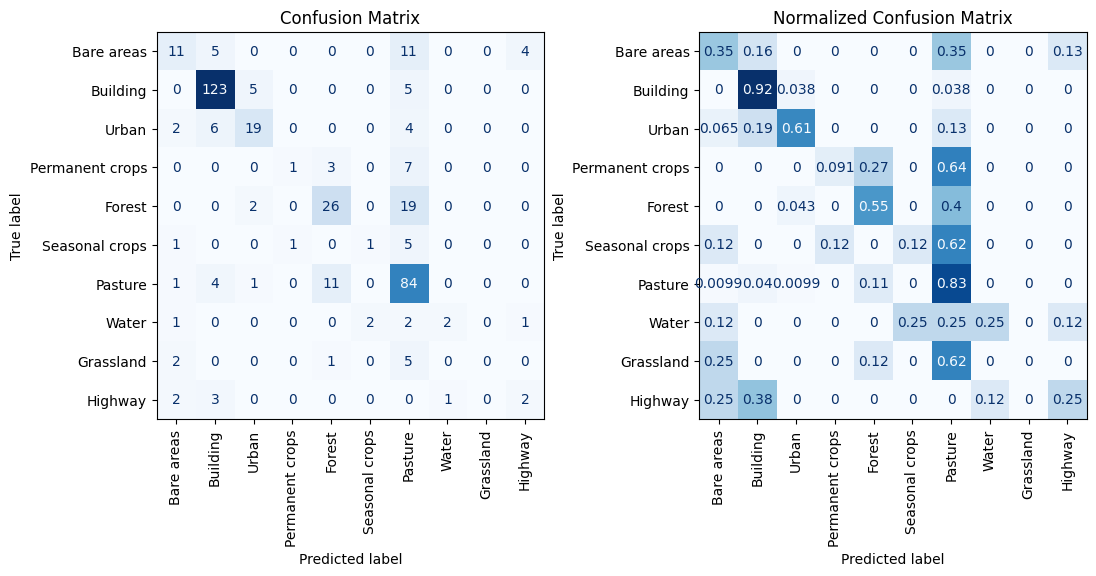

Overall Accuracy after Hyperparameter Tuning: 0.6968911917098446
                 precision    recall  f1-score   support

     Bare areas       0.55      0.35      0.43        31
       Building       0.87      0.92      0.90       133
         Forest       0.63      0.55      0.59        47
      Grassland       1.00      0.00      0.00         8
        Highway       0.29      0.25      0.27         8
        Pasture       0.59      0.83      0.69       101
Permanent crops       0.50      0.09      0.15        11
 Seasonal crops       0.33      0.12      0.18         8
          Urban       0.70      0.61      0.66        31
          Water       0.67      0.25      0.36         8

       accuracy                           0.70       386
      macro avg       0.61      0.40      0.42       386
   weighted avg       0.69      0.70      0.67       386



In [24]:
from sklearn.metrics import classification_report

best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1_macro')

print("%0.2f f1_macro with a standard deviation of %0.2f" % (scores.mean(), scores.std()))


overall,classification = compute_accuracy(best_model, X_test, y_test, train_gdf)
print("Overall Accuracy after Hyperparameter Tuning:", overall)
print(classification)


In [14]:
import pandas as pd 

mdi_importances = pd.Series(
    rf.feature_importances_, index=features
).sort_values(ascending=True)
print(mdi_importances)

solidity          0.005805
r_std             0.031998
eccentricity      0.033259
r_var             0.034361
g_median          0.037290
g_std             0.039691
g_mean            0.040745
r_median          0.044074
g_var             0.044720
r_mean            0.048441
b_median          0.052250
mean_intensity    0.053501
compactness       0.055629
b_var             0.063069
b_std             0.066642
b_mean            0.067022
shape_index       0.069706
area              0.098632
perimeter         0.113166
dtype: float64


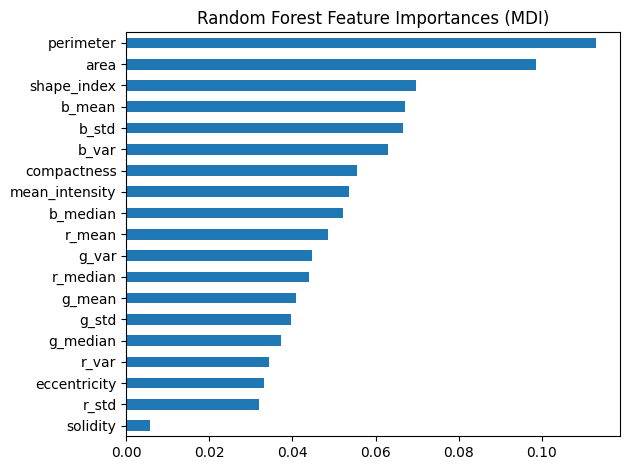

In [13]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()